# Escalate on Confidence

**When the fast judge is unsure, ask the slow one — and measure whether that was worth it.**

Every judgment in notebooks 10–12 came back with a number beside it: a `confidence` on each `Choice`, a
probability on each `Noul`. The TypeSafe docs describe a pattern built on exactly that number —
[confidence-gated routing](https://docs.typesafe.ai/patterns/confidence-routing.md), and its cousin the
[extraction cascade](https://docs.typesafe.ai/cookbooks/sde_cascade.md): let the System One model decide
everything it is sure about, and send the rest to something more expensive.

This repo already has the something more expensive. `kgx.llm.ClaudeCLI` runs Claude Haiku through the
`claude` CLI, cached to disk, and notebook 03 used it as an escalation target for whole documents. Here
the unit is the **edge judgment from notebook 10**: for each of GLiNER's 170 edges, *does the document
connect these two things* and *how does it present the claim*. The cascade sends the edges the System One
model was unsure about to Claude, keeps its answer for those, and the gate proceeds as before.

Three things get measured against the 47 gold triples: the System One gate alone (notebook 10's 0.404),
the cascade at every width of the uncertainty band, and Claude judging every edge — the upper bound of
escalating, and its cost. Then the same on the resolution side, where the adjudicator's `review` outcome
was designed as an escalation queue.

Needs `TYPESAFE_API_KEY` and the `claude` CLI, or the cached responses under `output/`.

## 0. Setup

In [1]:
import os, sys, time, json, warnings
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "src"))
warnings.filterwarnings("ignore")
os.environ["TOKENIZERS_PARALLELISM"] = "false"

import msgspec
import pandas as pd
import matplotlib.pyplot as plt
pd.set_option("display.width", 210)
pd.set_option("display.max_colwidth", 46)

import kgx
import kgx.typesafe as kts
from kgx.llm import ClaudeCLI
from kgx.evaluate import score_triples, graph_triples, comparison_table, MatchPolicy
from kgx.data.documents import DOCUMENTS, ALIAS_GROUPS, GOLD_DOC_FACTS
from kgx.extract import DocGraph

MATCH = MatchPolicy(normalize_names=True, use_aliases=True)
ONTO = kgx.BUSINESS_NEWS

ts = kts.CachedTypeSafe(cache_dir=ROOT / "output" / "typesafe_cache")
print(ts)

CachedTypeSafe(model='jev-latest', cache_dir='../output/typesafe_cache', key=unset)


In [2]:
extractor = kgx.GlinerExtractor()
graphs = extractor.extract_batch(DOCUMENTS, ONTO)
mentions = [m for g in graphs for m in g.mentions]
resolver = kgx.EntityResolver().learn_aliases(d["text"] for d in DOCUMENTS)
resolution = resolver.resolve(mentions)

def score(doc_graphs):
    kg = kgx.build_graph(doc_graphs, resolution, ONTO)
    return score_triples(graph_triples(kg), GOLD_DOC_FACTS, policy=MATCH, aliases=ALIAS_GROUPS)

def gate(doc_graphs, keep):
    out = []
    for g in doc_graphs:
        kept = [e for e in g.edges
                if (g.doc_id, g.mention(e.head).text, e.type, g.mention(e.tail).text) in keep]
        out.append(DocGraph(doc_id=g.doc_id, text=g.text, mentions=list(g.mentions),
                            edges=kept, feasible=g.feasible, meta=dict(g.meta)))
    return out

# Notebook 10's judgments, replayed from the same cache.
judgments = kts.judge_edges(ts, graphs, ONTO, max_questions=24)
J = pd.DataFrame([j.as_record() for j in judgments])
jev_keep = {(j.doc_id, j.head, j.relation, j.tail) for j in judgments if j.keep}
s_jev = score(gate(graphs, jev_keep))
print(f"{len(J)} edges; System One gate: P {s_jev.precision:.3f}  R {s_jev.recall:.3f}  F1 {s_jev.f1:.3f}")

170 edges; System One gate: P 0.404  R 0.404  F1 0.404


---

## 1. Where the fast judge is unsure

Two numbers per edge. `supported` is a `Noul`, so its uncertainty is its distance from 0.5. `status` is a
`Choice`, so its uncertainty is `confidence` — how concentrated the four-way distribution is. An edge is
*uncertain* when either says so.

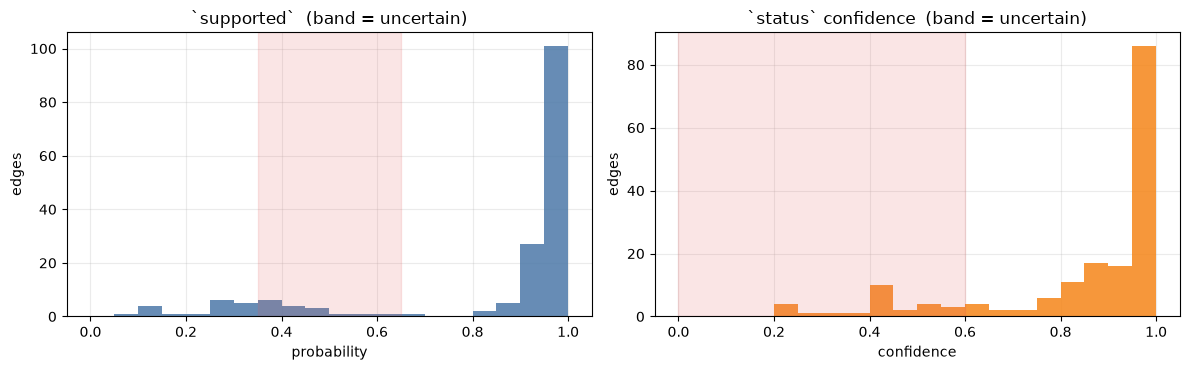

uncertain edges at the default band: 31 / 170 (18%), in 6 of 10 documents


,doc_id,head,relation,tail,gliner,supported,status,status_conf,keep,uncertain
125,d08,Northwind Logistics,operates_in,Arizona,0.534,0.13,negated,0.20,False,True
122,d08,Northwind Logistics,operates_in,Arizona,0.518,0.23,negated,0.21,False,True
111,d07,Northwind Logistics Inc.,reports_metric,revenue,0.399,0.42,hypothetical,0.23,False,True
110,d07,Northwind Logistics Inc.,reports_metric,revenue,0.572,0.47,hypothetical,0.24,False,True
112,d07,Northwind Logistics Inc.,reports_metric,revenue,0.519,0.40,hypothetical,0.28,False,True
123,d08,Northwind Logistics,operates_in,Alberta,0.597,0.45,asserted,0.34,False,True
26,d01,Northwind Logistics,partners_with,Cascade Freight Systems,0.546,0.39,hypothetical,0.37,False,True
25,d01,Northwind Logistics,partners_with,Cascade Freight Systems,0.528,0.38,hypothetical,0.40,False,True
27,d01,Northwind Logistics Inc.,partners_with,Cascade Freight Systems,0.540,0.36,hypothetical,0.40,False,True
30,d01,Northwind Logistics,partners_with,Cascade Freight Systems,0.582,0.39,hypothetical,0.41,False,True


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 3.8))
axes[0].hist(J["supported"], bins=20, range=(0, 1), color="#4C78A8", alpha=0.85)
axes[0].axvspan(0.35, 0.65, color="#E45756", alpha=0.15)
axes[0].set_title("`supported`  (band = uncertain)"); axes[0].set_xlabel("probability")
axes[1].hist(J["status_conf"], bins=20, range=(0, 1), color="#F58518", alpha=0.85)
axes[1].axvspan(0, 0.6, color="#E45756", alpha=0.15)
axes[1].set_title("`status` confidence  (band = uncertain)"); axes[1].set_xlabel("confidence")
for ax in axes:
    ax.grid(alpha=0.25); ax.set_axisbelow(True); ax.set_ylabel("edges")
plt.tight_layout(); plt.show()

def uncertain(row, band=(0.35, 0.65), min_conf=0.6):
    return (band[0] <= row["supported"] <= band[1]) or (row["status_conf"] < min_conf)

J["uncertain"] = J.apply(uncertain, axis=1)
print(f"uncertain edges at the default band: {int(J['uncertain'].sum())} / {len(J)} "
      f"({J['uncertain'].mean():.0%}), in {J[J['uncertain']]['doc_id'].nunique()} of 10 documents")
display(J[J["uncertain"]].sort_values("status_conf").head(10))

---

## 2. The slow judge

Claude Haiku, through the `claude` CLI, one call per **document** — every edge in that document in one
prompt, the same four assertion statuses with the same descriptions, JSON out. Per-document batching is
the honest cost model for escalation: an application that escalates any edge in a document pays for the
document once. `ClaudeCLI` caches every response, so a re-run replays.

Asking Claude about every edge here — not only the uncertain ones — costs the same ten calls and gives the
upper bound for free: what escalating *everything* would buy.

In [4]:
SCHEMA = {
    "type": "object",
    "properties": {
        "edges": {
            "type": "array",
            "items": {
                "type": "object",
                "properties": {
                    "i": {"type": "integer"},
                    "supported": {"type": "boolean"},
                    "status": {"type": "string", "enum": list(kts.ASSERTION_LEVELS)},
                },
                "required": ["i", "supported", "status"],
            },
        }
    },
    "required": ["edges"],
}

llm = ClaudeCLI(model="haiku", cache_dir=ROOT / "output" / "llm_cache", json_schema=SCHEMA)
print("claude CLI:", llm.check() if llm.available else "not on PATH (cache only)")

STATUS_TEXT = "\n".join(f"  {k}: {v}" for k, v in kts.ASSERTION_LEVELS.items())

def claude_prompt(graph, edges):
    desc = {r.name: r.description for r in ONTO.relations}
    claims = "\n".join(
        f"  {i}. \u201c{graph.mention(e.head).text}\u201d \u2014 {e.type} \u2192 "
        f"\u201c{graph.mention(e.tail).text}\u201d   ({e.type}: {desc.get(e.type, '')})"
        for i, e in enumerate(edges))
    return (
        "Judge each numbered claim against the document.\n\n"
        "For each claim answer two things:\n"
        "  supported: true if the document says anything that bears on this claim between these two "
        "specific things, in any modality (asserted, denied, proposed, possible); false if the document "
        "does not connect them.\n"
        "  status: how the document presents the claim, one of:\n" + STATUS_TEXT + "\n\n"
        "Judge only how the claim is presented, not whether it is plausible.\n\n"
        f"DOCUMENT:\n{graph.text}\n\nCLAIMS:\n{claims}\n\n"
        'Return JSON: {"edges": [{"i": <claim number>, "supported": <bool>, "status": <status>}, ...]} '
        "with one entry per claim."
    )

t0 = time.perf_counter()
claude_rows = []
for g in graphs:
    edges = [e for e in g.edges if not e.derived]
    out = llm.complete_json(claude_prompt(g, edges))
    by_i = {int(r["i"]): r for r in out.get("edges", [])}
    for i, e in enumerate(edges):
        r = by_i.get(i)
        claude_rows.append({
            "doc_id": g.doc_id, "head": g.mention(e.head).text, "relation": e.type,
            "tail": g.mention(e.tail).text,
            "claude_supported": (1.0 if r["supported"] else 0.0) if r else float("nan"),
            "claude_status": r["status"] if r else None,
        })
claude_s = time.perf_counter() - t0
C = pd.DataFrame(claude_rows)
print(f"{len(C)} edges judged by Claude in {claude_s:.1f}s; answered {int(C['claude_status'].notna().sum())}")
print(llm.stats())

claude CLI: 2.1.275 (Claude Code)
170 edges judged by Claude in 0.0s; answered 170
{'model': 'haiku', 'live_calls': 0, 'cache_hits': 10, 'cost_usd_this_run': 0.0, 'cost_usd_observed': 0.0698, 'live_seconds': 0.0, 'mean_latency_ms': 3768}


---

## 3. The cascade, scored

Three systems and one rule. *System One alone* is notebook 10. *Claude alone* uses Claude's answer for every
edge. *The cascade* uses Claude's answer where System One was uncertain and System One's everywhere else.

In [5]:
# Both frames were built in the same per-document edge order (judge_edges and the
# Claude loop both skip derived edges), so align by position: a key merge would
# multiply rows, because GLiNER emits the same surface triple several times in one
# document (`partners_with(Northwind, SEC)` four times in d07).
assert len(C) == len(J)
assert (C[["doc_id", "head", "relation", "tail"]].values == J[["doc_id", "head", "relation", "tail"]].values).all()
M = pd.concat([J.reset_index(drop=True), C[["claude_supported", "claude_status"]].reset_index(drop=True)], axis=1)

def keep_set(frame, supported_col, status_col):
    return {(r.doc_id, r.head, r.relation, r.tail) for r in frame.itertuples()
            if getattr(r, supported_col) >= 0.5 and getattr(r, status_col) == "asserted"}

M["casc_supported"] = M.apply(lambda r: r["claude_supported"] if r["uncertain"] and pd.notna(r["claude_supported"]) else r["supported"], axis=1)
M["casc_status"] = M.apply(lambda r: r["claude_status"] if r["uncertain"] and r["claude_status"] else r["status"], axis=1)

systems = {
    "System One gate  (notebook 10)": keep_set(M, "supported", "status"),
    "cascade: uncertain -> Claude":  keep_set(M, "casc_supported", "casc_status"),
    "Claude on every edge":          keep_set(M.dropna(subset=["claude_status"]), "claude_supported", "claude_status"),
    "no gate":                       {(r.doc_id, r.head, r.relation, r.tail) for r in M.itertuples()},
}
results = {name: score(gate(graphs, keep)) for name, keep in systems.items()}
display(comparison_table(results))
print("edges kept: " + ", ".join(f"{n} {len(k)}" for n, k in systems.items()))

,policy,predicted,gold,matched,precision,recall,f1
system,,,,,,,
System One gate (notebook 10),normalised + aliases,47,47,19,0.404,0.404,0.404
cascade: uncertain -> Claude,normalised + aliases,48,47,19,0.396,0.404,0.400
Claude on every edge,normalised + aliases,51,47,19,0.373,0.404,0.388
no gate,normalised + aliases,68,47,19,0.279,0.404,0.330


edges kept: System One gate  (notebook 10) 69, cascade: uncertain -> Claude 71, Claude on every edge 76, no gate 102


In [6]:
# Where the two judges disagree on the uncertain edges, and what the cascade actually changed.
U = M[M["uncertain"]].copy()
U["jev_keep"] = (U["supported"] >= 0.5) & (U["status"] == "asserted")
U["claude_keep"] = (U["claude_supported"] >= 0.5) & (U["claude_status"] == "asserted")
flipped = U[U["jev_keep"] != U["claude_keep"]]
print(f"uncertain edges: {len(U)}   Claude disagrees on the keep/drop decision for {len(flipped)}")
print(f"   dropped by System One, kept by Claude: {int((~flipped['jev_keep']).sum())}")
print(f"   kept by System One, dropped by Claude: {int(flipped['jev_keep'].sum())}")
display(flipped[["doc_id", "head", "relation", "tail", "supported", "status", "status_conf",
                 "claude_supported", "claude_status"]].head(14))

uncertain edges: 31   Claude disagrees on the keep/drop decision for 3
   dropped by System One, kept by Claude: 3
   kept by System One, dropped by Claude: 0


,doc_id,head,relation,tail,supported,status,status_conf,claude_supported,claude_status
0,d01,Northwind Logistics Inc.,acquires,Cascade Freight Systems,0.99,hypothetical,0.50,1.0,asserted
1,d01,Northwind Logistics Inc.,acquires,Cascade Freight Systems,0.99,hypothetical,0.48,1.0,asserted
163,d10,Arizona summer peak pricing,impacts,Phoenix,0.97,negated,0.44,1.0,asserted


**The cascade is worse than not cascading, by one spurious triple.** System One alone: F1 0.404. Send the
31 uncertain edges to Claude and it is 0.400; let Claude judge all 170 and it is 0.388. Recall never
moves — every system recovers the same 19 gold triples — so the whole difference is precision, and it
runs the wrong way.

Claude disagreed with System One on the keep/drop decision for 3 of the 31, all in the same direction:
things System One dropped, Claude kept. Two are `acquires(Northwind, Cascade)` in d01, which System One
called `hypothetical` at confidence 0.50 and 0.48 — the document says both *"entered into a definitive
agreement to acquire"* and *"the proposed acquisition, if approved"*, so a coin-flip confidence is the
honest answer and Claude's `asserted` is defensible; it changes nothing, because the same triple is
asserted plainly in d02 and d09. The third is `impacts(Arizona summer peak pricing, Phoenix)`, which System
One called `negated` at 0.44 and Claude called `asserted`. It is not a gold triple. That is the 0.004.

The other 28 uncertain edges, Claude and System One agreed on. Which is the quieter finding: the edges the
fast judge was unsure about were, by the slow judge's lights, mostly decided correctly anyway.

### 3.1 Every width of the band

The band is a policy, not a fact, and the routing pattern's whole point is that it can be tuned against
cost. Sweep the `status` confidence cutoff from *escalate nothing* to *escalate everything* and read the
frontier: F1 against the fraction of edges (and documents) that went to the slow judge. No request is
made; both judges' answers are already on disk.

,edges escalated,share,documents escalated,precision,recall,f1
conf cutoff,,,,,,
0.00,0,0.00,0,0.404,0.404,0.404
0.30,18,0.11,5,0.404,0.404,0.404
0.40,18,0.11,5,0.404,0.404,0.404
0.50,24,0.14,6,0.396,0.404,0.400
0.60,31,0.18,6,0.396,0.404,0.400
0.70,35,0.21,6,0.396,0.404,0.400
0.80,40,0.24,7,0.396,0.404,0.400
0.90,68,0.40,8,0.373,0.404,0.388
0.95,81,0.48,9,0.373,0.404,0.388


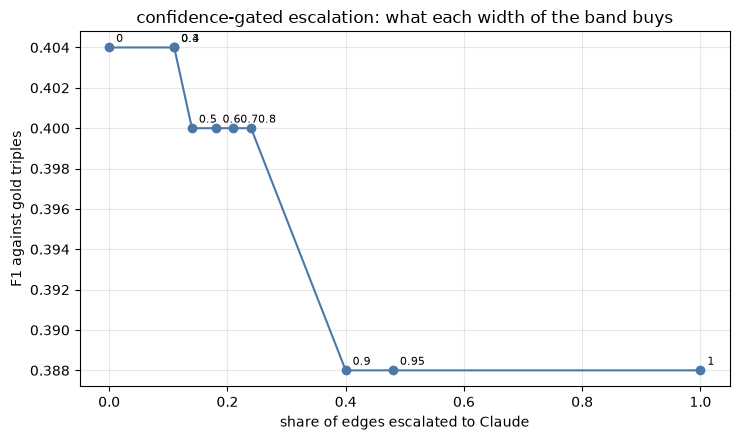

In [7]:
sweep = []
for cut in [0.0, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 0.95, 1.01]:
    esc = (M["status_conf"] < cut) | ((M["supported"] >= 0.35) & (M["supported"] <= 0.65) & (cut > 0))
    sup = M["supported"].where(~esc, M["claude_supported"]).fillna(M["supported"])
    st = M["status"].where(~esc, M["claude_status"]).fillna(M["status"])
    keep = {(r.doc_id, r.head, r.relation, r.tail) for r, s_, t_ in zip(M.itertuples(), sup, st)
            if s_ >= 0.5 and t_ == "asserted"}
    s = score(gate(graphs, keep))
    sweep.append({"conf cutoff": cut, "edges escalated": int(esc.sum()),
                  "share": round(esc.mean(), 2),
                  "documents escalated": M[esc]["doc_id"].nunique(),
                  "precision": round(s.precision, 3), "recall": round(s.recall, 3), "f1": round(s.f1, 3)})
SW = pd.DataFrame(sweep)
display(SW.set_index("conf cutoff"))

fig, ax = plt.subplots(figsize=(7.5, 4.5))
ax.plot(SW["share"], SW["f1"], "o-", color="#4C78A8")
for _, r in SW.iterrows():
    ax.annotate(f"{r['conf cutoff']:.2g}", (r["share"], r["f1"]), textcoords="offset points",
                xytext=(5, 4), fontsize=8)
ax.set_xlabel("share of edges escalated to Claude"); ax.set_ylabel("F1 against gold triples")
ax.set_title("confidence-gated escalation: what each width of the band buys")
ax.grid(alpha=0.3); plt.tight_layout(); plt.show()

**Flat, then down.** Escalating the least confident 11% of edges (18, in five documents) changes nothing;
from 14% on the F1 is 0.400; from 40% on it is Claude's 0.388. There is no width of the band at which the
slow judge improves on the fast one, so the best escalation rate on this corpus is zero — and the pattern
still did its job, because the number that says so is the same number the pattern is built on. A routing
policy that can be swept at no cost and shown to have an optimum at zero is worth more than one that was
assumed to help.

---

## 4. The resolution side: `review` was built for this

Notebook 10's pair adjudicator has a middle level — *closely related, may or may not be the same* — that
the entity-alignment cookbook calls the curator queue. In the review band, 14 of 55 pairs landed there.
Send exactly those to Claude, with the same two mentions and their contexts, and ask for the same
three-way call.

In [8]:
from kgx.resolve import ScoredPair

GOLD = {}
for canon, aliases in ALIAS_GROUPS.items():
    surfaces = {a.strip() for a in aliases}
    for m in mentions:
        if m.text.strip() in surfaces:
            GOLD[m.mention_id] = canon
MENTION = {m.mention_id: m for m in mentions}

band = resolution.review_band(low=0.70)
verdicts = kts.adjudicate_pairs(ts, band, MENTION)           # replayed from notebook 10's cache
review = [(p, v) for p, v in zip(band, verdicts) if v.outcome == "review"]
print(f"{len(band)} pairs in the band; {len(review)} landed on `review`")

def gold_verdict(p):
    ga, gb = GOLD.get(p.a), GOLD.get(p.b)
    if ga is None or gb is None:
        return "unlabelled"
    return "same" if ga == gb else "different"

PAIR_SCHEMA = {"type": "object",
               "properties": {"decision": {"type": "string", "enum": ["same", "different", "unsure"]},
                              "reason": {"type": "string"}},
               "required": ["decision"]}
llm_pairs = ClaudeCLI(model="haiku", cache_dir=ROOT / "output" / "llm_cache", json_schema=PAIR_SCHEMA)

def pair_prompt(ma, mb):
    return ("Two mentions from a business-news corpus, each with the sentence it appeared in. "
            "Do they refer to the same real-world entity?\n\n"
            f"A: \u201c{ma.text}\u201d ({ma.type})\n   context: {ma.context}\n\n"
            f"B: \u201c{mb.text}\u201d ({mb.type})\n   context: {mb.context}\n\n"
            'Return JSON: {"decision": "same" | "different" | "unsure", "reason": "<one sentence>"}')

rows = []
for p, v in review:
    out = llm_pairs.complete_json(pair_prompt(MENTION[p.a], MENTION[p.b]))
    rows.append({"a": MENTION[p.a].text, "b": MENTION[p.b].text, "type": p.type,
                 "system one level": round(v.level, 2), "claude": out.get("decision"),
                 "reason": (out.get("reason") or "")[:70], "gold": gold_verdict(p)})
R = pd.DataFrame(rows)
display(R)
print(pd.crosstab(R["claude"], R["gold"]).to_string())
print(f"\n{llm_pairs.stats()}")

55 pairs in the band; 14 landed on `review`


,a,b,type,system one level,claude,reason,gold
0,Northwind,Northwind Logistics,company,0.98,different,Mention A refers to a general company with...,same
1,Northwind,Northwind Logistics Inc.,company,1.24,unsure,"While ""Northwind"" could be a shortened ref...",same
2,Northwind,Northwind Logistics Inc.,company,1.11,different,The entities have different legal names (N...,same
3,Northwind,Northwind Logistics,company,0.87,unsure,The contexts refer to different business a...,same
4,Northwind,Northwind Logistics,company,1.03,unsure,"While both mention ""Northwind,"" one is ref...",same
5,Northwind,Northwind Logistics,company,1.03,unsure,While both mentions are from business cont...,same
6,Adjusted operating margin,operating margin,financial_metric,1.43,same,Both mentions refer to the same financial ...,unlabelled
7,freight brokerage,freight,sector,1.45,different,"While both mention ""Northwind Logistics"" i...",unlabelled
8,non-GAAP gross margin,non-GAAP earnings per share,financial_metric,1.03,different,These are two distinct financial metrics (...,unlabelled
9,freight brokerage,Freight,sector,1.18,different,Mention A refers to the freight brokerage ...,unlabelled


gold       same  unlabelled
claude                     
different     2           7
same          0           1
unsure        4           0

{'model': 'haiku', 'live_calls': 0, 'cache_hits': 14, 'cost_usd_this_run': 0.0, 'cost_usd_observed': 0.0539, 'live_seconds': 0.0, 'mean_latency_ms': 3578}


**On the pairs System One hedged, Claude Haiku was wrong where it was confident.** Six of the fourteen
`review` pairs are gold-same — `Northwind` against `Northwind Logistics` and `Northwind Logistics Inc.` —
the prefix matches the resolver held at 0.880 and the adjudicator put at levels 0.87–1.24, *closely
related, may or may not be the same*. Claude called two of them `different` (*"the entities have different
legal names"*) and four `unsure`. **Zero of six** right, against an adjudicator that had, correctly,
declined to decide.

That is the useful thing about this section. The `review` level exists so that a *curator* can look; it
does not follow that a larger language model is a curator. Haiku, handed the two mentions and their
contexts, reasoned its way to *different* on a pair that is the same company — fluently, in a sentence, at
3.6 seconds and $0.004 a pair. The adjudicator's 1.03 with no explanation was the better answer.

The eight unlabelled pairs are where Claude and the adjudicator broadly agree: `Adjusted operating margin`
/ `operating margin` is the one Claude called `same`, and it is.

---

## 5. What it cost

In [9]:
print("System One (replayed from notebook 10):")
display(pd.Series(ts.stats()).to_frame("value"))
print("\nClaude, edges (per document):", llm.stats())
print("Claude, review pairs:", llm_pairs.stats())

System One (replayed from notebook 10):


,value
requests_live,0.0
requests_cached,73.0
questions,560.0
questions_per_request,7.7
input_tokens_billed,0.0
output_tokens_billed,0.0
input_tokens_observed,107306.0
output_tokens_observed,16531.0
ms_spent,0.0
ms_per_request_observed,179.6



Claude, edges (per document): {'model': 'haiku', 'live_calls': 0, 'cache_hits': 10, 'cost_usd_this_run': 0.0, 'cost_usd_observed': 0.0698, 'live_seconds': 0.0, 'mean_latency_ms': 3768}
Claude, review pairs: {'model': 'haiku', 'live_calls': 0, 'cache_hits': 14, 'cost_usd_this_run': 0.0, 'cost_usd_observed': 0.0539, 'live_seconds': 0.0, 'mean_latency_ms': 3578}


---

## 6. Findings

*Measured on this repo's corpus, not asserted. Reproducible from `output/typesafe_cache/` and
`output/llm_cache/`.*

In [10]:
print("=" * 78)
print("SUMMARY".center(78))
print("=" * 78)
for name, s in results.items():
    print(f"  {name:<34} P {s.precision:.3f}  R {s.recall:.3f}  F1 {s.f1:.3f}")
best = SW.loc[SW["f1"].idxmax()]
print(f"\n  best band: conf < {best['conf cutoff']:.2g} -> {int(best['edges escalated'])} edges "
      f"({best['share']:.0%}) in {int(best['documents escalated'])} documents, F1 {best['f1']:.3f}")
print(f"  uncertain edges at default band: {int(J['uncertain'].sum())}; Claude flipped {len(flipped)}")
print(f"  review pairs escalated: {len(R)}   Claude: {R['claude'].value_counts().to_dict()}")
print("=" * 78)

                                   SUMMARY                                    
  System One gate  (notebook 10)     P 0.404  R 0.404  F1 0.404
  cascade: uncertain -> Claude       P 0.396  R 0.404  F1 0.400
  Claude on every edge               P 0.373  R 0.404  F1 0.388
  no gate                            P 0.279  R 0.404  F1 0.330

  best band: conf < 0 -> 0 edges (0%) in 0 documents, F1 0.404
  uncertain edges at default band: 31; Claude flipped 3
  review pairs escalated: 14   Claude: {'different': 9, 'unsure': 4, 'same': 1}


### Escalation bought nothing on this corpus, and the sweep is the proof rather than the assumption

F1 0.404 with the System One gate alone; 0.400 sending the 31 least-confident edge judgments to Claude
Haiku; 0.388 sending all 170. Recall is identical throughout — 19 gold triples — so the difference is
entirely precision, and it falls as escalation rises. Sweeping the band from 0% to 100% of edges shows no
width at which the slow judge helps. The confidence-routing pattern worked exactly as designed: the same
number that would have routed the escalation is the number that showed it was not worth routing.

### The uncertain edges were mostly decided right

Claude agreed with System One on 28 of the 31 edges it was unsure about. Of the three it flipped, two are
the d01 acquisition — hedged at 0.50 by a document that both announces a definitive agreement and calls it
proposed, a coin flip that is the honest answer — and one is a spurious `impacts` edge that Claude asserted
and System One had dropped. Low confidence here meant *the text is genuinely ambiguous*, not *the fast
model is out of its depth*; a bigger model does not resolve ambiguity that is in the source.

### A larger model is not a curator

Fourteen pairs the adjudicator put in the review queue went to Claude Haiku. On the six that are gold-same
— `Northwind` / `Northwind Logistics Inc.` — Haiku got none right: two `different` on the grounds of
*"different legal names"*, four `unsure`. The adjudicator had placed them at 0.87–1.24 and declined to
decide. Escalating a `review` outcome to a generative model traded a calibrated abstention for a confident
error, at twenty times the latency. The middle level was designed for a person with a reference to hand,
and that is still what it is for.

### What the slow judge costs, measured

Ten document-level calls, $0.070, 3.8 s each; fourteen pair calls, $0.054, 3.6 s each. Against 73 System
One requests at 180 ms, replayed here from cache at no cost. Notebook 03 found Claude slightly ahead of
GLiNER as an *extractor*; as a *judge of GLiNER's edges*, on the questions notebook 10 asks, Haiku is not
ahead of the System One model — and the cascade's purpose is to find out where it would be, at a price
the sweep can put a number on.